## NCR STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

ncr=pd.read_csv('../stock_data/ncr.csv') ## so it can be small letter. This is cool.
ncr=ncr.drop(columns=['high_price','low_price'])
ncr.rename(columns={'trade_date':'date'},inplace=True)
ncr['date']=pd.to_datetime(ncr['date'])
ncr['month']=ncr['date'].dt.month
ncr['quarter']=ncr['date'].dt.quarter
ncr['year']=ncr['date'].dt.year

ncr

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42838,NCR,2017-01-03,8.53,8.53,1190,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43398,NCR,2017-01-04,8.53,8.53,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43508,NCR,2017-01-05,8.53,8.53,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43618,NCR,2017-01-06,8.53,8.53,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43708,NCR,2017-01-09,8.53,8.53,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298103,NCR,2026-07-13,161.20,161.20,1107,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298541,NCR,2026-07-14,161.20,161.20,2900,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298979,NCR,2026-07-15,161.20,161.20,2404,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299417,NCR,2026-07-16,161.20,161.20,516,2026-07-16T15:10:03.113936+00:00,7,3,2026


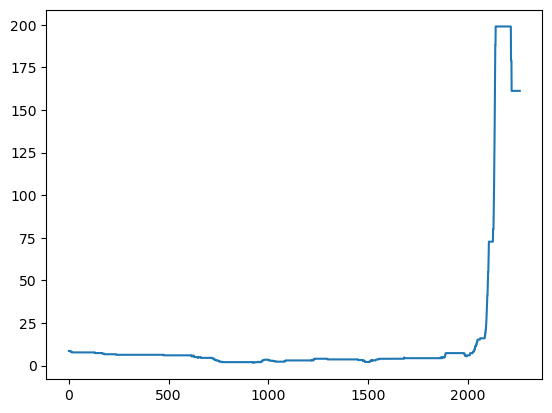

In [2]:
import matplotlib.pyplot as plt

plt.plot(ncr['close_price'])
plt.show()

In [3]:
ncr_end_month_df = (
    ncr
    .sort_values("date")
    .groupby(ncr["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

ncr_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45408,NCR,2017-01-31,7.71,7.71,864,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47230,NCR,2017-02-28,7.71,7.71,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49346,NCR,2017-03-31,7.71,7.71,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51173,NCR,2017-04-28,7.71,7.71,400,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53096,NCR,2017-05-31,7.71,7.71,100,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35340,NCR,2026-03-31,199.00,199.00,15981,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281166,NCR,2026-04-30,199.00,199.00,11110,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284232,NCR,2026-05-29,161.20,161.20,8350,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294160,NCR,2026-06-30,161.20,161.20,1551,2026-06-30T15:10:03.08168+00:00,6,2,2026


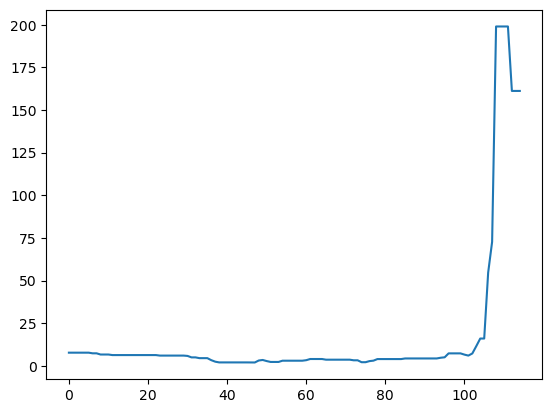

In [4]:
plt.plot(ncr_end_month_df['close_price'])
plt.show()

In [5]:
ncr_end_month_df['returns']=ncr_end_month_df['close_price'].pct_change()*100
ncr_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45408,NCR,2017-01-31,7.71,7.71,864,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47230,NCR,2017-02-28,7.71,7.71,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49346,NCR,2017-03-31,7.71,7.71,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51173,NCR,2017-04-28,7.71,7.71,400,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53096,NCR,2017-05-31,7.71,7.71,100,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35340,NCR,2026-03-31,199.00,199.00,15981,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281166,NCR,2026-04-30,199.00,199.00,11110,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
112,284232,NCR,2026-05-29,161.20,161.20,8350,2026-05-29T15:00:02.455558+00:00,5,2,2026,-18.994975
113,294160,NCR,2026-06-30,161.20,161.20,1551,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


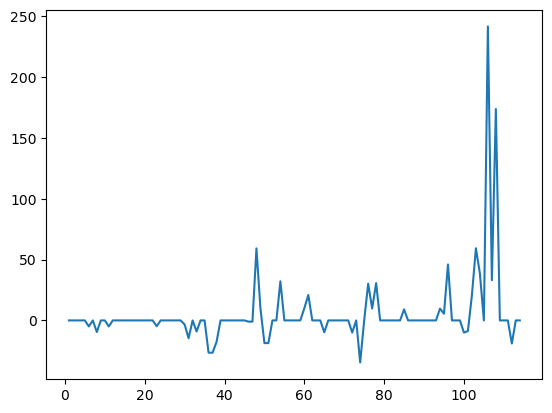

In [6]:
plt.plot(ncr_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(ncr_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-4.540640608616571, 0.00016593412398874035, 3, 110, {'1%': -3.4912451337340342, '5%': -2.8881954545454547, '10%': -2.5809876033057852}, 961.6074129793889)
stationary


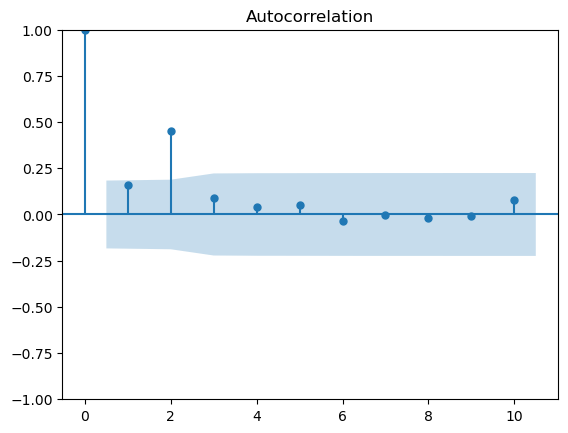

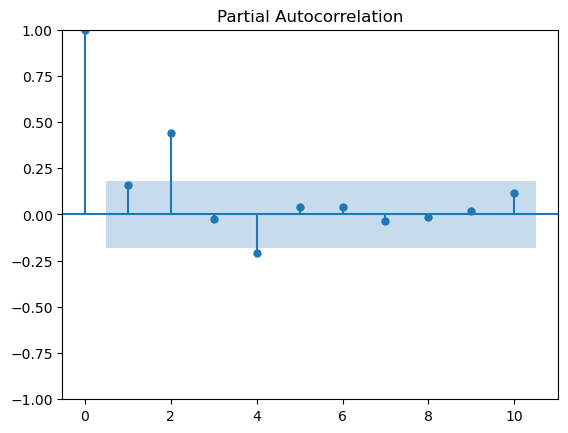

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ncr_end_month_df['returns'].dropna(), lags=10)
plot_pacf(ncr_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ncr_end_month_df['close_price'][:-10]
test=ncr_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -4.774363598860302]
[0, 0, 0, 0, 0, 1, -4.520569548906374]
[0, 0, 0, 0, 0, 2, -4.418434079095013]
[0, 0, 0, 0, 1, 0, -4.326731706597608]
[0, 0, 0, 0, 1, 1, -4.307568802778147]
[0, 0, 0, 0, 1, 2, -4.309786213961206]
[0, 0, 0, 0, 2, 0, -4.1617074849666045]
[0, 0, 0, 0, 2, 1, -4.224809556654108]
[0, 0, 0, 0, 2, 2, -4.229385947868253]
[0, 0, 0, 1, 0, 0, -4.348608355358399]
[0, 0, 0, 1, 0, 1, -4.3342456958824185]
[0, 0, 0, 1, 0, 2, -4.338991772534495]
[0, 0, 0, 1, 1, 0, -4.3071842259912785]
[0, 0, 0, 1, 1, 1, -4.312214990544226]
[0, 0, 0, 1, 1, 2, -4.313861545683624]
[0, 0, 0, 1, 2, 0, -4.192681557492892]
[0, 0, 0, 1, 2, 1, -4.22740484141712]
[0, 0, 0, 1, 2, 2, -4.206448729418877]
[0, 0, 0, 2, 0, 0, -4.335196602394208]
[0, 0, 0, 2, 0, 1, -4.337148906123427]
[0, 0, 0, 2, 0, 2, -4.339163762906923]
[0, 0, 0, 2, 1, 0, -4.307382246563594]
[0, 0, 0, 2, 1, 1, -4.312093468070289]
[0, 0, 0, 2, 1, 2, -4.306994002868568]
[0, 0, 0, 2, 2, 0, -4.270548363034692]
[0, 0, 0, 2, 2, 1, -4.2

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-4.774364
27,0,0,1,0,0,0,-4.769324
54,0,0,2,0,0,0,-4.759543
55,0,0,2,0,0,1,-4.543065
28,0,0,1,0,0,1,-4.530341
...,...,...,...,...,...,...,...
204,0,2,1,1,2,0,-2.061396
420,1,2,0,1,2,0,-2.029902
177,0,2,0,1,2,0,-2.024829
411,1,2,0,0,2,0,-1.994642


In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ncr_end_month_df['returns'].dropna()[:-10]
test=ncr_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.2575954658548767]
[0, 0, 0, 0, 0, 1, -0.2762888952232976]
[0, 0, 0, 0, 0, 2, -0.2783866119446521]
[0, 0, 0, 0, 1, 0, 0.0019628898767845016]
[0, 0, 0, 0, 1, 1, -0.18976012306156154]
[0, 0, 0, 0, 1, 2, -0.22758352993354425]
[0, 0, 0, 0, 2, 0, 0.18070823223445986]
[0, 0, 0, 0, 2, 1, 0.032904638908254014]
[0, 0, 0, 0, 2, 2, -0.14100077524564547]
[0, 0, 0, 1, 0, 0, -0.2769712810370768]
[0, 0, 0, 1, 0, 1, -0.2769597203769989]
[0, 0, 0, 1, 0, 2, -0.28940259101922994]
[0, 0, 0, 1, 1, 0, -0.10847979432475086]
[0, 0, 0, 1, 1, 1, -0.21105377963750094]
[0, 0, 0, 1, 1, 2, -0.2128550818033106]
[0, 0, 0, 1, 2, 0, 0.0983038018755672]
[0, 0, 0, 1, 2, 1, -0.04925759612146652]
[0, 0, 0, 1, 2, 2, -0.12683756761369747]
[0, 0, 0, 2, 0, 0, -0.27688969919209905]
[0, 0, 0, 2, 0, 1, -0.2745920006328335]
[0, 0, 0, 2, 0, 2, -0.301451609676022]
[0, 0, 0, 2, 1, 0, -0.200994383344147]
[0, 0, 0, 2, 1, 1, -0.2220438884441771]
[0, 0, 0, 2, 1, 2, -0.20677573794761495]
[0, 0, 0, 2, 2, 0, 6.821249702

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
185,0,2,0,2,1,2,-2.095667
188,0,2,0,2,2,2,-1.955705
184,0,2,0,2,1,1,-1.922727
655,2,2,0,0,2,2,-1.895535
176,0,2,0,1,1,2,-1.861341
...,...,...,...,...,...,...,...
195,0,2,1,0,2,0,0.287226
330,1,1,0,0,2,0,0.296125
572,2,1,0,0,2,0,0.301836
222,0,2,2,0,2,0,0.304001


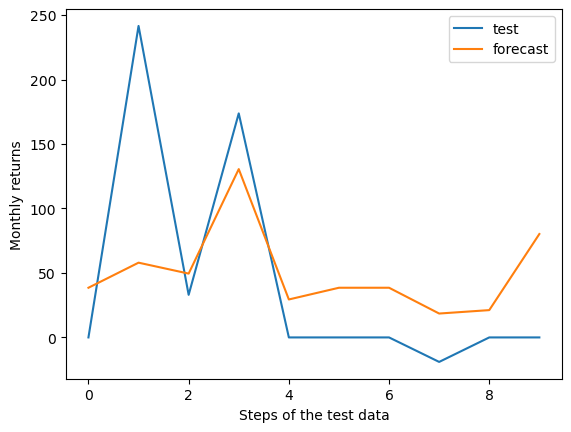

r2_score:  0.3089069059209353
rmse:  70.32081028549254
description:  count    114.000000
mean       5.147342
std       30.671011
min      -34.567901
25%        0.000000
50%        0.000000
75%        0.000000
max      241.562500
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=ncr_end_month_df['returns'].dropna()[:-10]
y_test=ncr_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,0), 
seasonal_order=(0,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', ncr_end_month_df.returns.dropna().describe())

Very horrible but we will work with this.
